# §6.1 recovery sweep plots

Mechanism check + robustness for the soft causal prior in modified FasterRisk. Loads `results/causal_prior/synthetic/recovery_p30_headline/`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))

from src.causal_prior.loading import load_recovery_csvs
from src.causal_prior import visualization as viz

ROOT = Path.cwd().parents[2]
recovery = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_p30_headline')

In [2]:
# drop PC q sources: Fisher-Z PC on dense Gaussian DAGs returns near-noise q
# (anti-informative at p_edge >= 0.3, worse than vanilla in all but the
# cleanest cells). Discussed as a finding rather than shown in headline.
# Comment out to inspect PC in an appendix figure.
recovery = recovery[~recovery['q_source'].str.startswith('pc')]

# anchor cell = (p=30, n=300, k_star=5, p_edge=0.2); each sweep varies one dim, others fixed
pe_sweep = recovery.query('p == 30 and n == 300 and k_star == 5')        # vary p_edge
n_sweep  = recovery.query('p == 30 and k_star == 5 and p_edge == 0.2')   # vary n
p_sweep  = recovery.query('n == 300 and k_star == 5 and p_edge == 0.2')  # vary p
k_sweep  = recovery.query('p == 30 and n == 300 and p_edge == 0.2')      # vary k_star

## Headline: precision vs $p_\mathrm{edge}$ at $\mu_\mathrm{rel}=1$

One panel, all $q$ sources, sweeping confounding density. Vanilla precision (gray dotted "vanilla" = uniform $q$, mathematically equivalent to $\mu=0$) is the reference. Curves are essentially flat in $\mu$ for $\mu_\mathrm{rel} \in [10^{-2}, 10]$ (FasterRisk's integer-beta beam search is robust to penalty scale).

The gap between causal-informed $q$ (oracle, GES) and vanilla grows monotonically with $p_\mathrm{edge}$: ~0 at 0.1, ~0.25 at 0.7. Adversarial collapses to ~0 everywhere, confirming the mechanism reflects $q$ quality. GES exceeds oracle at $p_\mathrm{edge} \geq 0.4$: smooth informative $q$ outperforms the spike-oracle ceiling, suggesting the prior benefits from distributional information over hard $S^*$ membership. bootstrap-$L_1$ tracks vanilla closely: predictive-only stability selection adds no causal information beyond what FR's search already exploits.

<Axes: title={'center': '$p_{\\mathrm{edge}}$ sweep ($\\mu_{\\mathrm{rel}}=0.81$)'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='S precision'>

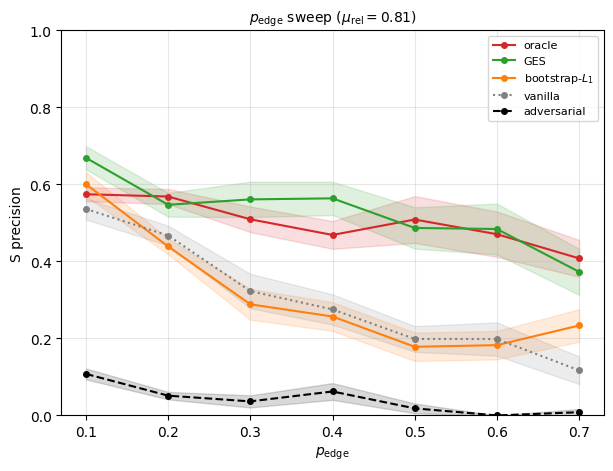

In [3]:
viz.plot_recovery_vs_axis(pe_sweep, axis_col='p_edge')

## Robustness sweeps (precision vs axis at $\mu_\mathrm{rel}=1$)

Anchor the headline op-point ($p=30, n=300, k^*=5, p_\mathrm{edge}=0.2, \mu_\mathrm{rel}=1$) and sweep each dimension one at a time. Vanilla (gray dotted, $=$ uniform $q$) is the no-prior reference and varies with the axis itself.

### $n$ sweep (sample size)
$n \in \{75, 100, 150, 200, 300, 500, 1000\}$. All sources rise modestly with $n$; gap between oracle/GES and vanilla stays small (~0.05) and roughly constant. The prior is robust across sample sizes but doesn't preferentially help small-$n$; sample efficiency isn't where this mechanism shines.

<Axes: title={'center': '$n$ sweep ($\\mu_{\\mathrm{rel}}=0.81$)'}, xlabel='$n$', ylabel='S precision'>

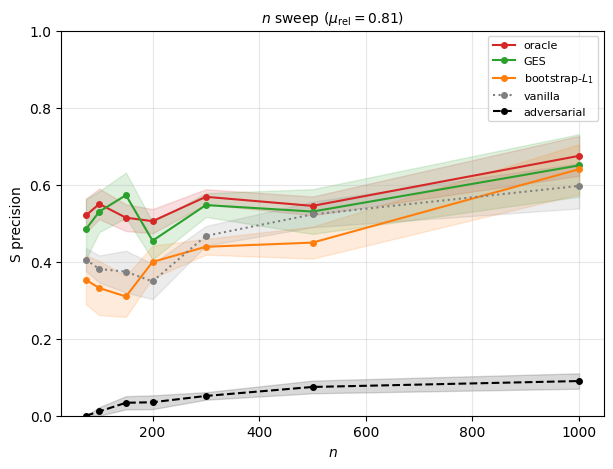

In [4]:
viz.plot_recovery_vs_axis(n_sweep, axis_col='n')

### $p$ sweep (feature count)
$p \in \{10, 15, 20, 30, 50\}$. Gap GES vs vanilla widens from ~0 at $p=10$ to ~0.3 at $p=50$. Mechanism scales with feature count, confirming the prior matters most when there are many candidate features competing for $K$ slots.

<Axes: title={'center': '$p$ sweep ($\\mu_{\\mathrm{rel}}=0.81$)'}, xlabel='$p$', ylabel='S precision'>

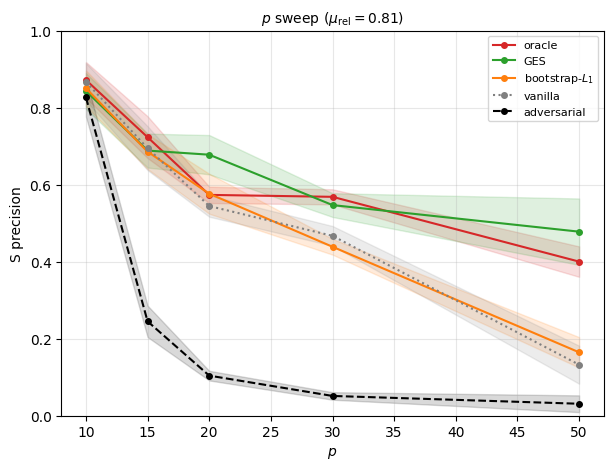

In [5]:
viz.plot_recovery_vs_axis(p_sweep, axis_col='p')

### $k^*$ sweep (target sparsity)
$k^* \in \{3, 5, 7\}$, with $K = 2 k^*$ in FR so the headroom always equals the truth. Mechanism stable across target sparsity; q-source ranking preserved. No regime where the prior breaks down at small or large $k^*$.

<Axes: title={'center': '$k^{*}$ sweep ($\\mu_{\\mathrm{rel}}=0.81$)'}, xlabel='$k^{*}$', ylabel='S precision'>

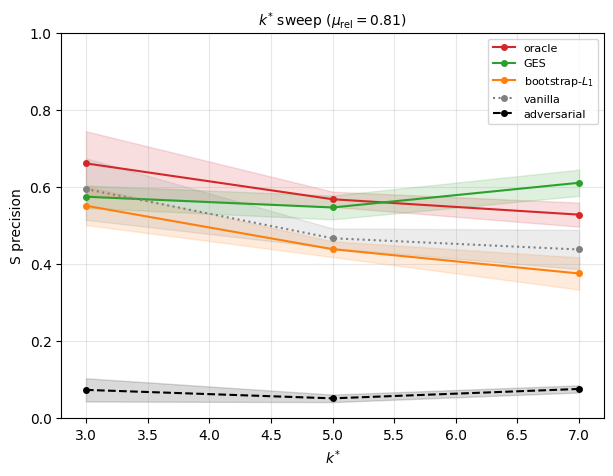

In [6]:
viz.plot_recovery_vs_axis(k_sweep, axis_col='k_star')

## Soft prior vs hard pre-selection (§6.4)

For each soft $q$ source (GES, bootstrap-$L_1$; PC dropped per the headline note), soft at $\mu_\mathrm{rel}=1$ vs hard pre-selection at $t \in \{0.3, 0.5, 0.7\}$, as a function of $p_\mathrm{edge}$. Soft tracks the best hard threshold across $p_\mathrm{edge}$, but the best threshold itself varies with $p_\mathrm{edge}$ (no single $t$ wins everywhere). This is the §6.4 argument: soft avoids a hyperparameter that hard would have to tune per cell.

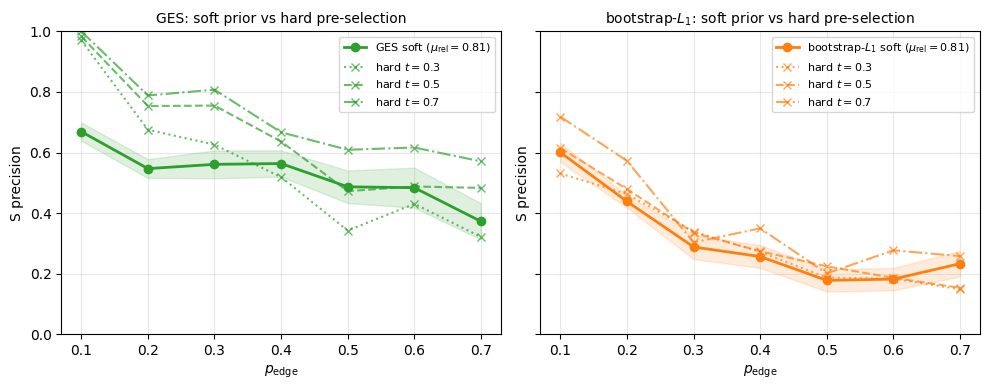

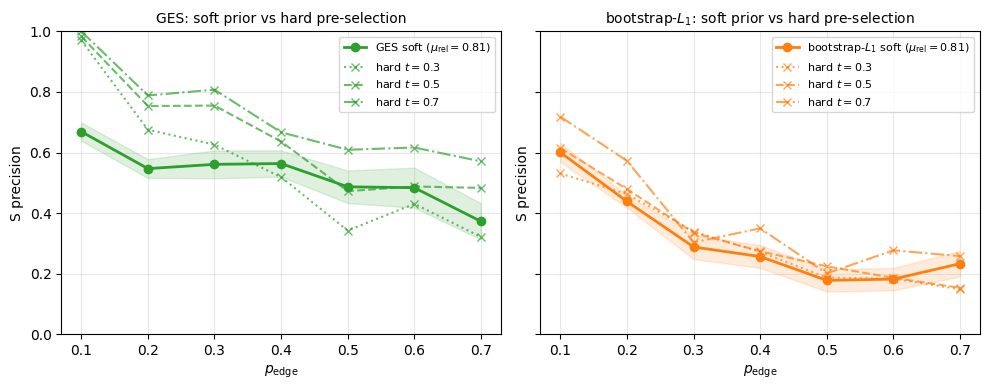

In [7]:
viz.plot_soft_vs_hard_facet(pe_sweep, q_sources=['ges', 'bootstrap_l1'], ncols=2)